> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy


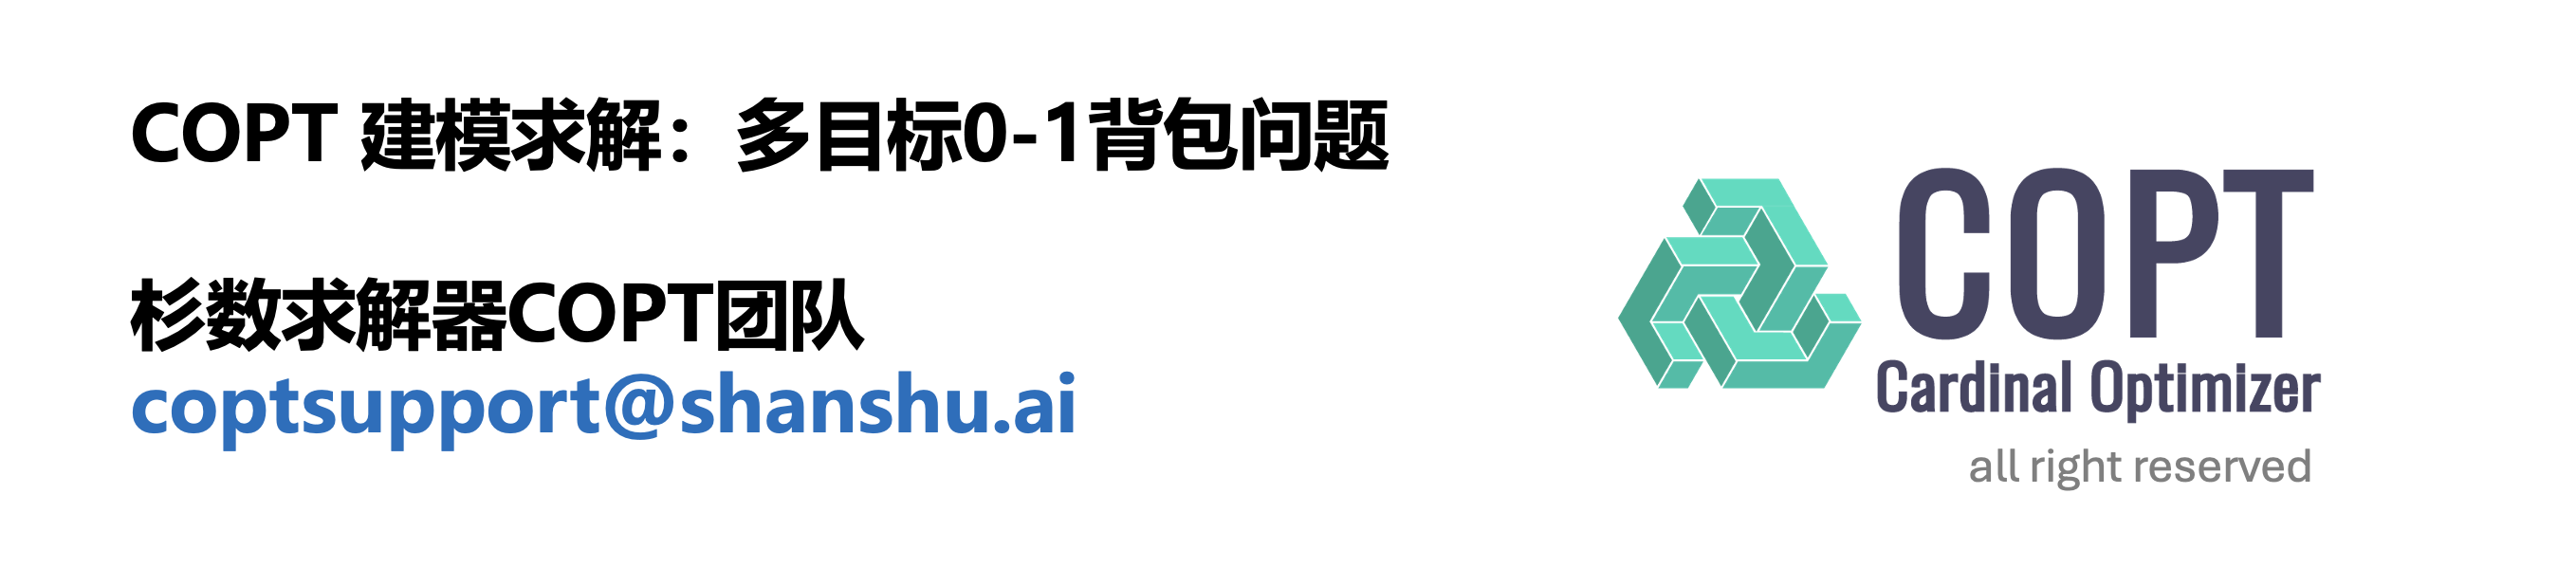

# 单目标0-1背包问题代码实现
### 使用COPT建模求解0-1整数规划的步骤

首先，我们来看一个单目标0-1背包问题。

使用COPT在 Python 中求解单目标0-1背包问题的基本步骤如下：

1. 导入 COPT-Python接口库：``coptpy``

2. 添加或导入数据（可选）

3. 创建**COPT环境**和**COPT模型**

4. 构建优化模型  
   按如下顺序添加模型三要素：
   - **决策变量**：添加0-1（二进制）决策变量 $x_i \in \{0,1\}$，表示是否选择第 $i$ 个物品，使用 ``Model.addVar()``，其中指定参量 ``vtype=COPT.BINARY``； 
   - **目标函数**：最大化背包内物品总价值 $\sum p_i x_i$，使用 ``Model.setObjective()`` ，其中指定参量 ``sense=COPT.MAXIMIZE`` ；
   - **约束条件**：添加背包容量（线性）约束 $\sum a_i x_i \leq b$，使用 ``Model.addConstr()`` 添加线性约束。

5. 调用COPT求解器求解上述0-1整数规划模型

6. 查看并解释结果


## 导入COPT-Python接口库

In [4]:
import coptpy as cp
from coptpy import COPT

## 添加模型数据

此处我们添加的模型数据对应于数学模型中定义的集合和参数，这里用到都是Python内置的基础数据结构。

- $n$：物品总数  
- $p_i$：物品 $i$ 的价值  $(i = 0, 1, 2, \dots, n-1)$
- $w_i$：物品 $i$ 的重量  
- $v_i$：物品 $i$ 的体积 
- $W$：背包的重量上限  
- $V$：背包的体积容量上限  

In [6]:
# value
p = [9, 2, 5, 4, 90, 70, 6]   
# item amount
n = len(p)
# weight
w = [3, 15, 2, 4, 2, 14, 16]   
# volume
v = [2, 3, 1, 2, 1, 4, 3]  
# volume capacity
V = 15  
# weight limit
W = 50

## 创建求解环境和求解模型

In [8]:
# Create COPT environment
env = cp.Envr()
# Create model object
m = env.createModel('knapsack')

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型三要素

### 添加决策变量

在0-1背包问题中，每个物品是否放入的决策通过0-1变量来刻画。

$$
x_i =
\begin{cases}
1, & \text{若选择了物品 } i \\
0, & \text{若未选择物品 } i
\end{cases}
$$

这里我们指定变量的数量为 ``n`` ，批量添加一组0-1变量（ ``COPT.BINARY`` ）。

In [10]:
x = m.addVars(n, vtype=COPT.BINARY)

### 设置目标函数

单目标0-1背包问题的目标函数为最大化（ ``sense=COPT.MAXIMIZE`` ）放入背包内所有物品的价值总和，这是一个线性目标。

$$
\max \sum_{i=0}^{n-1} p_i x_i
$$

我们用 ``Model.setObjective()`` 设置目标函数，线性目标函数的表达式通过 ``quicksum()`` 来构造，语法和代数表达式非常接近。

In [12]:
# Objective 1: minimize total weight, lower priority
m.setObjective(
    cp.quicksum(p[i]*x[i] for i in range(n)),
    sense=COPT.MAXIMIZE
)

<font color=#0000FF>
<b>提示：推荐使用quicksum()</b>
</font>   

这里我们用到COPT中的辅助函数quicksum()实现加和运算。虽然和Python中的内置函数sum()实现的功能一致，但是使用quicksum()的性能更好，它对求和过程进行了优化，因此速度更快、占用内存空间更少，比调用sum()（或直接使用加号运算符）性能上会好很多，特别针对大规模问题建模时。

### 添加约束条件

我们需要满足的有重量约束和体积容量约束。

1.所选物品的总重量不能超过背包重量上限 $W$：

$$
\sum_{i=0}^{n-1} w_i x_i \leq W
$$

我们用 ``m.addConstr()`` 添加单条线性约束，约束左端项的线性表达式同样通过 ``cp.quicksum()`` 来构造；
约束表达式中的系数 ``w`` 和右端项 ``W`` 为此前定义的物品重量列表和重量上限常数。

In [15]:
# weight constraint
m.addConstr(cp.quicksum(w[i]*x[i] for i in range(n)) <= W)

<coptpy.Constraint: >

2.所选物品的总体积不能超过背包容量上限 $V$：

$$
\sum_{i=0}^{n-1} v_i x_i \leq V
$$

我们用 ``m.addConstr()`` 添加单条线性约束，约束左端项的线性表达式同样通过 ``cp.quicksum()`` 来构造；
约束表达式中的系数 ``v`` 和右端项 ``V`` 为此前定义的物品体积列表和容量上限常数。

In [17]:
# volumne constraint
m.addConstr(cp.quicksum(v[i]*x[i] for i in range(n)) <= V)

<coptpy.Constraint: >

## 求解与获取结果

建模完成后，调用 ``Model.solve()`` 函数求解以上模型。

In [19]:
# Solve
m.solve()

Model fingerprint: 6c70b9e9

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing a MIP problem

The original problem has:
    2 rows, 7 columns and 14 non-zero elements
    7 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

Problem was solved during presolve

Best solution   : 184.000000000
Best bound      : 184.000000000
Best gap        : 0.0000%
Solve time      : 0.01
Solve node      : 0
MIP status      : solved
Solution status : integer optimal (relative gap limit 0.0001)

Violations      :     absolute     relative
    bounds      :            0            0
    rows        :            0            0
    integrality :            0


In [20]:
# Output results
if m.status == COPT.OPTIMAL:
    print("Optimal total value:", m.objval)
    print("\nSelected items:")
    print("{:<6} {:<6} {:<6} {:<6}".format("Item", "Value", "Weight", "Volume"))
    print("-" * 26)
    total_value = 0
    total_weight = 0
    total_volume = 0
    for i in range(n):
        if x[i].getInfo(COPT.Info.Value) > 0.5:
            print("{:<6} {:<6} {:<6} {:<6}".format(i, p[i], w[i], v[i]))
            total_value += p[i]
            total_weight += w[i]
            total_volume += v[i]
    print("-" * 26)
    print("{:<6} {:<6} {:<6} {:<6}".format("Sum", total_value, total_weight, total_volume))
else:
    print("No optimal solution found.")

Optimal total value: 184.0

Selected items:
Item   Value  Weight Volume
--------------------------
0      9      3      2     
2      5      2      1     
3      4      4      2     
4      90     2      1     
5      70     14     4     
6      6      16     3     
--------------------------
Sum    184    41     13    


# 多目标0-1背包问题代码实现

### 使用COPT建模求解多目标优化问题的步骤

使用COPT在 Python 中求解多目标0-1背包问题的基本步骤如下：

1. 导入 COPT-Python接口库：``coptpy``

2. 添加或导入数据（可选）

3. 创建**COPT环境**和**COPT模型**

4. 构建优化模型  
   按如下顺序添加模型三要素：
   - **决策变量**：添加0-1（二进制）决策变量 $x_i \in \{0,1\}$，表示是否选择第 $i$ 个物品，使用 ``Model.addVar()``，其中指定参量 ``vtype=COPT.BINARY``； 
   - **目标函数**：调用 ``Model.setObjectiveN()`` 设置多个目标函数，通过参数 ``priority`` 或 ``weight`` 可以指定优先级或权重；
       - 目标1：最大化背包内物品总价值 $\max\quad\sum p_i x_i$，指定 ``priority=2`` ，优先级较高；
       - 目标2：最小化背包内物品总重量 $\min\quad\sum w_i x_i$，指定 ``priority=1`` ，优先级较低。
   - **约束条件**：添加背包容量（线性）约束 $\sum v_i x_i \leq V$，使用 ``Model.addConstr()`` 添加线性约束。

5. 调用COPT求解器求解上述多目标0-1整数规划模型

6. 查看并解释结果

## 创建求解环境和求解模型

我们在最开始的COPT环境中创建一个新的模型对象，用于表示多目标优化模型。

In [23]:
# Create model object
m2 = env.createModel('knapsack_multi')

## 添加模型三要素

### 添加决策变量

在多目标的0-1背包问题中，决策变量的构造和单目标的一致。

$$
x_i =
\begin{cases}
1, & \text{若选择了物品 } i \\
0, & \text{若未选择物品 } i
\end{cases}
$$

这里我们指定变量的数量为 ``n`` ，批量添加一组0-1变量（ ``COPT.BINARY`` ）。

In [25]:
x = m2.addVars(n, vtype=COPT.BINARY)

### 设置多目标函数


**目标 1：最大化总价值**

目标函数为最大化（ ``sense=COPT.MAXIMIZE`` ）放入背包内所有物品的价值总和，这是一个线性目标。

$$
\max \sum_{i=0}^{n-1} p_i x_i
$$

该目标用于衡量被选中物品所带来的总收益。我们将其设置为主要优化目标，并赋予较高的优先级（priority = 2）。

**目标 2：最小化总重量**

目标函数为最小化（ ``sense=COPT.MINIMIZE`` ）放入背包内所有物品的总重量，这同样是一个线性目标。

$$
\min \sum_{i=0}^{n-1} w_i x_i
$$

该目标用于在不影响总价值最大化前提下，进一步最小化总重量。我们将其设置为次要目标，并赋予较低的优先级（priority = 1）。

通过函数的入参 ``priority`` 为不同的目标指定优先级，COPT在求解时采用 **分层法** ，保证高优先级目标最优的基础上，优化次优先级的目标。

In [27]:
# Objective 1: maximize total value, higher priority
m2.setObjectiveN(
    1,
    cp.quicksum(p[i]*x[i] for i in range(n)),
    priority=2.0,
    sense=COPT.MAXIMIZE
)

In [28]:
# Objective 2: minimize total weight, lower priority
m2.setObjectiveN(
    2,
    cp.quicksum(w[i]*x[i] for i in range(n)), 
    priority=1.0,
    sense=COPT.MINIMIZE
)

<font color=#0000FF>
<b>提示：COPT多目标优化功能</b>
</font>   

COPT于7.2.8版本开始支持多目标优化功能，目前支持线性（连续或离散均可）的目标函数。通过调用Model类的成员方法 ``Model.setObjectiveN()`` 设置目标函数，并且可以为每个目标函数指定对应的优先级 ``priority`` 和权重 ``weight`` 等；在求解多目标模型时，COPT采用分层法（hierarchy method）和加权组合法（weighted-sum method）。具体请参考 [《COPT用户手册：多目标优化》](https://guide.coap.online/copt/zh-doc/multiobj.html)


### 添加约束条件

在单目标优化中，我们需要满足的有重量约束和体积容量约束；在多目标优化模型中，我们将 $\min\quad\sum w_i x_i$ 作为目标之一，因此需要满足的约束只有体积约束：

所选物品的总体积不能超过背包容量上限 $V$：

$$
\sum_{i=0}^{n-1} v_i x_i \leq V
$$


In [31]:
# volumne constraint
m2.addConstr(cp.quicksum(v[i]*x[i] for i in range(n)) <= V)

<coptpy.Constraint: >

## 求解与获取结果

建模完成后，调用 ``Model.solve()`` 函数求解以上模型。

In [33]:
# Solve
m2.solve()

Model fingerprint: 1a8df2ce

Start the multi-objective optimization with 2 objectives

Using hierarchy method for 2 objective groups

Solving the 0-th objective group (priority=2)

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    1 rows, 7 columns and 7 non-zero elements
    7 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

Problem was solved during presolve

Best solution   : -184.000000000
Best bound      : -184.000000000
Best gap        : 0.0000%
Solve time      : 0.01
Solve node      : 0
MIP status      : solved
Solution status : integer optimal (relative gap limit 0.0001)

Violations      :     absolute     relative
    bounds      :            0            0
    rows        :            0            0
    integrality :   

以上是多目标优化的求解日志，可以看出求解的顺序是按照priority进行的。

## 获取结果

我们用到 ``Model.getAttrN(idx, attrname)`` 来获取多目标优化的结果，支持获取的多目标函数属性值包括： "HasQObj" ，"HasNLObj" ， "LpObjval" ， "BestObj" ， "ObjSense" ， "ObjConst" 。

In [35]:
# Output results
if m2.status == COPT.OPTIMAL:
    print("Optimal total value:", m2.getAttrN(1, "BestObj"))
    print("Optimal total weight:", m2.getAttrN(2, "BestObj"))
    print("\nSelected items:")
    print("{:<6} {:<6} {:<6} {:<6}".format("Item", "Value", "Weight", "Volume"))
    print("-" * 26)
    total_value = 0
    total_weight = 0
    total_volume = 0
    for i in range(n):
        if x[i].getInfo(COPT.Info.Value) > 0.5:
            print("{:<6} {:<6} {:<6} {:<6}".format(i, p[i], w[i], v[i]))
            total_value += p[i]
            total_weight += w[i]
            total_volume += v[i]
    print("-" * 26)
    print("{:<6} {:<6} {:<6} {:<6}".format("Sum", total_value, total_weight, total_volume))
else:
    print("No optimal solution found.")

Optimal total value: 184.0
Optimal total weight: 41.0

Selected items:
Item   Value  Weight Volume
--------------------------
0      9      3      2     
2      5      2      1     
3      4      4      2     
4      90     2      1     
5      70     14     4     
6      6      16     3     
--------------------------
Sum    184    41     13    
